In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from xgboost import XGBRegressor
import shap
from lime import lime_tabular
from sklearn.inspection import PartialDependenceDisplay


In [19]:
# Loading dataset
df = pd.read_csv('/Users/kyriakospapadopoulos/Desktop/University/Big Blue Data Academy/Personal/Assets/household_income.csv')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [23]:
df['Income_log'] = np.log(df['Income'])

In [25]:
df["Education_Level"] = df["Education_Level"].replace({"High School" : 0, 
                                                      "Bachelor's" : 1,
                                                      "Master's" : 2, 
                                                      "Doctorate" : 3})

/var/folders/qz/tlkqc8n13j16h_7zq8yfc6th0000gn/T/ipykernel_2085/251153810.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Education_Level"] = df["Education_Level"].replace({"High School" : 0,


In [27]:
categorical_columns = ['Gender', 'Occupation', 'Location', 'Marital_Status', 'Employment_Status', 'Homeownership_Status', 'Type_of_Housing', 'Primary_Mode_of_Transportation']  # Non-ordinal features
ordinal_columns = ['Education_Level']
numerical_columns = ['Age', 'Number_of_Dependents' , 'Work_Experience', 'Household_Size'] 

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first'), categorical_columns),
        ('ordinal', 'passthrough', ordinal_columns)  # 'passthrough' since already manually encoded
    ]
)

In [31]:
X = df.drop(columns=['Income' , 'Income_log'])
y = df['Income_log']

In [33]:
models = [
    ('LinearRegression', LinearRegression(), {}),
    ('Lasso', Lasso(), {'model__alpha': [0.01, 0.1, 1, 10, 100]}),
    ('Ridge', Ridge(), {'model__alpha': [0.01, 0.1, 1, 10, 100]}),
    ('DecisionTree', DecisionTreeRegressor(random_state=42), {
        'model__max_depth': [None, 5, 10, 20, 30],
        'model__min_samples_split': [2, 10, 20],
        'model__min_samples_leaf': [1, 5, 10]
    }),
    ('RandomForest', RandomForestRegressor(random_state=42), {'model__n_estimators': [50, 100, 200],
                                                               'model__max_depth': [None, 10, 20, 30]}),
    ('XGBoost', XGBRegressor(objective='reg:squarederror', random_state=42), {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 7, 10],
        'model__learning_rate': [0.01, 0.1, 0.2]
    })
]

In [35]:
for name, model, param_grid in models:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scoring = {
        'neg_mean_squared_error': 'neg_mean_squared_error',
        'r2': 'r2',
        'mae': make_scorer(mean_absolute_error)
    }
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring=scoring, refit='neg_mean_squared_error')
    grid_search.fit(X, y)
    
    print(f"{name} - Best parameters: {grid_search.best_params_}")
    print(f"{name} - Best cross-validated MSE: {-grid_search.best_score_}")
    
    best_model_cv_results = grid_search.cv_results_
    best_index = grid_search.best_index_

    print(f"{name} - Best cross-validated R²: {best_model_cv_results['mean_test_r2'][best_index]}")
    print(f"{name} - Best cross-validated MAE: {best_model_cv_results['mean_test_mae'][best_index]}")
    print(f"{name} - Standard Deviation of MSE: {best_model_cv_results['std_test_neg_mean_squared_error'][best_index]}\n")

LinearRegression - Best parameters: {}
LinearRegression - Best cross-validated MSE: 2.2512298825626607
LinearRegression - Best cross-validated R²: 0.02787492126330602
LinearRegression - Best cross-validated MAE: 1.2055489329680305
LinearRegression - Standard Deviation of MSE: 0.04444589678083092

Lasso - Best parameters: {'model__alpha': 0.01}
Lasso - Best cross-validated MSE: 2.255162395557291
Lasso - Best cross-validated R²: 0.02616590492186428
Lasso - Best cross-validated MAE: 1.2147035947570912
Lasso - Standard Deviation of MSE: 0.04226873829344172

Ridge - Best parameters: {'model__alpha': 100}
Ridge - Best cross-validated MSE: 2.2507412456963607
Ridge - Best cross-validated R²: 0.028081349415769275
Ridge - Best cross-validated MAE: 1.2084422197760627
Ridge - Standard Deviation of MSE: 0.04340452347238218

DecisionTree - Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
DecisionTree - Best cross-validated MSE: 2.2007326073898583

---
### Observations:

- **Linear Regression:** Linear Regression provided a solid baseline with a cross-validated MSE of 2.251 and an R² of 0.0279. The model performed reasonably well compared to Lasso and Ridge, indicating that a simple linear approach can capture some of the variance in the target variable. However, the relatively low R² suggests that more complex models may be needed to fully capture the underlying patterns in the data.

- **Lasso vs. Ridge:** Ridge slightly outperformed Lasso, which aligns with expectations given that Ridge is generally more effective at handling correlated features without driving coefficients to zero. The small alpha for Lasso suggests that only minimal regularization was needed, whereas the larger alpha for Ridge indicates that this model benefited from stronger regularization. Both models, however, had relatively low R² values, indicating limited ability to capture the variance in the target variable.

- **Decision Tree:** The Decision Tree model demonstrated a modest improvement over Linear Regression, Lasso, and Ridge, with a cross-validated MSE of 2.201 and an R² of 0.0498. The model's ability to slightly increase performance suggests it could capture non-linear relationships better than the linear models. However, the performance is still limited, indicating that the Decision Tree model, despite some advantages, might not be sufficient on its own to capture all complexities in the data.

- **Random Forest:** The Random Forest model outperformed Linear Regression, Lasso, Ridge, and Decision Tree, achieving a lower cross-validated MSE of 2.127 and a higher R² of 0.0814. This improvement is expected, as Random Forests can better capture complex interactions and non-linear relationships in the data compared to linear models and even a single decision tree. The model's superior performance highlights its strength in handling more intricate patterns, making it more effective where simpler models fall short.

- **XGBoost:** XGBoost delivered the best overall performance among the models tested, with the lowest cross-validated MSE of 2.1 and the highest R² of 0.0896. This model's ability to fine-tune through boosting likely contributed to its superior handling of the data's complexities. The best parameters for XGBoost included a learning rate of 0.1, a max depth of 7, and 200 estimators, which together provided a balance between model complexity and generalization. 
---

In [37]:
# Binning the target variable for stratification
n_bins = 10  
binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
y_binned = binner.fit_transform(y.values.reshape(-1, 1)).ravel()

# Define stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
# Loop through models and apply stratified cross-validation
for name, model, param_grid in models:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scoring = {
        'neg_mean_squared_error': 'neg_mean_squared_error',
        'r2': 'r2',
        'mae': make_scorer(mean_absolute_error)
    }
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=skf.split(X, y_binned), scoring=scoring, refit='neg_mean_squared_error')
    grid_search.fit(X, y)
    
    print(f"{name} - Best parameters: {grid_search.best_params_}")
    print(f"{name} - Best cross-validated MSE: {-grid_search.best_score_}")
    
    best_model_cv_results = grid_search.cv_results_
    best_index = grid_search.best_index_

    print(f"{name} - Best cross-validated R²: {best_model_cv_results['mean_test_r2'][best_index]}")
    print(f"{name} - Best cross-validated MAE: {best_model_cv_results['mean_test_mae'][best_index]}")
    print(f"{name} - Standard Deviation of MSE: {best_model_cv_results['std_test_neg_mean_squared_error'][best_index]}\n")

LinearRegression - Best parameters: {}
LinearRegression - Best cross-validated MSE: 2.2472747906325
LinearRegression - Best cross-validated R²: 0.029802220631430388
LinearRegression - Best cross-validated MAE: 1.2049001599045928
LinearRegression - Standard Deviation of MSE: 0.020047644211780354

Lasso - Best parameters: {'model__alpha': 0.01}
Lasso - Best cross-validated MSE: 2.2522998089759367
Lasso - Best cross-validated R²: 0.02764102714212089
Lasso - Best cross-validated MAE: 1.2142586838200393
Lasso - Standard Deviation of MSE: 0.023544608248471065

Ridge - Best parameters: {'model__alpha': 100}
Ridge - Best cross-validated MSE: 2.247144834728452
Ridge - Best cross-validated R²: 0.029861455299221885
Ridge - Best cross-validated MAE: 1.2078332431905097
Ridge - Standard Deviation of MSE: 0.02100816802303634

DecisionTree - Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
DecisionTree - Best cross-validated MSE: 2.1981786347051626

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the XGBoost model with the best parameters found earlier
xgb_model = XGBRegressor(objective='reg:squarederror', learning_rate=0.1, max_depth=6, n_estimators=50, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

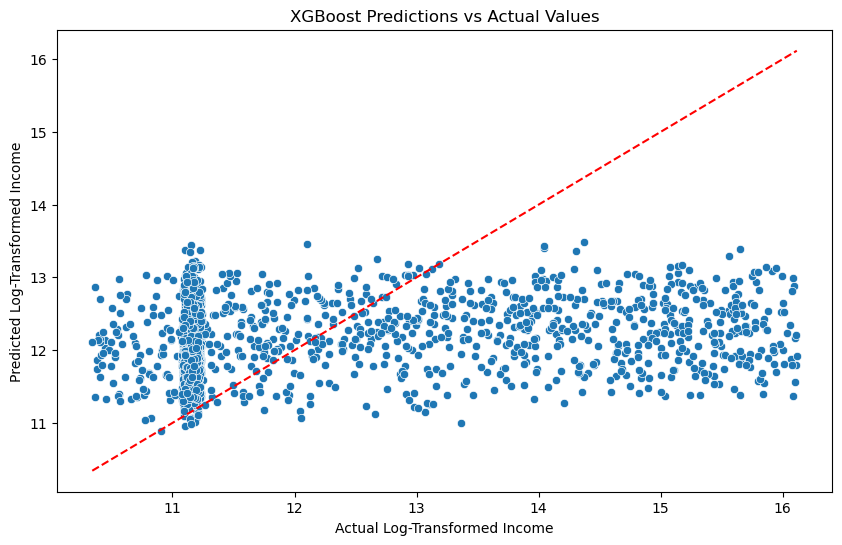

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Line of perfect prediction
plt.xlabel('Actual Log-Transformed Income')
plt.ylabel('Predicted Log-Transformed Income')
plt.title('XGBoost Predictions vs Actual Values')
plt.show()

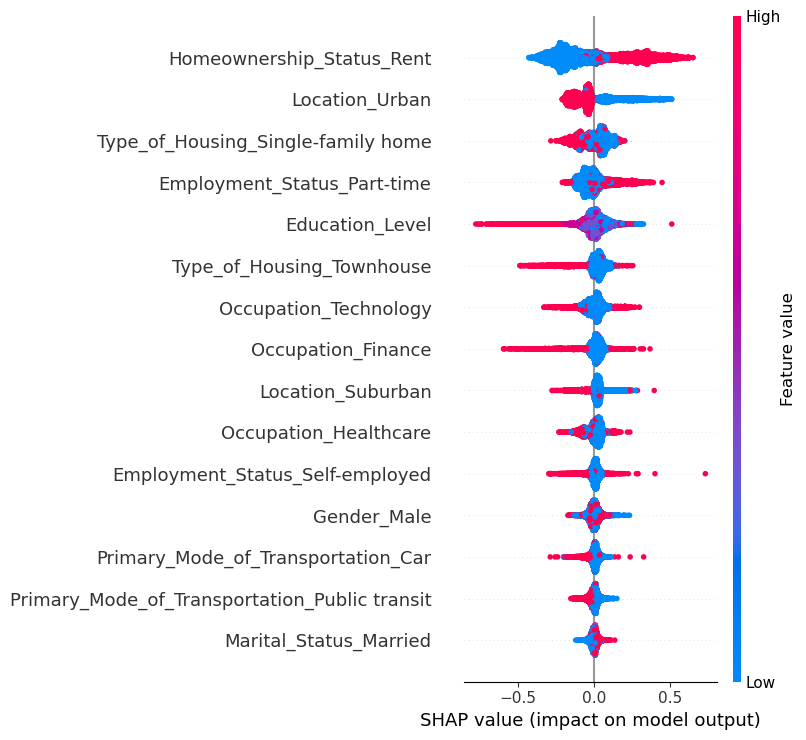

In [48]:
# Apply the preprocessor to the features
X_processed = preprocessor.transform(X)

# Convert to DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=preprocessor.get_feature_names_out())

# Remove the transformer prefixes
X_processed_df.columns = [col.split('__')[-1] for col in X_processed_df.columns]

# Now use this cleaned DataFrame for SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_processed_df)

# Plot the summary SHAP values (global feature importance)
shap.summary_plot(shap_values, X_processed_df, max_display=15)

### SHAP Summary Plot Analysis

The SHAP summary plot above provides a visual representation of the impact that each feature has on the model’s predictions of the log-transformed household income. Here are the key takeaways from this plot:

1. **Top Contributing Features:**
   - **Homeownership_Status_Rent:** This feature has the highest impact on the model’s predictions, with higher SHAP values generally pushing the prediction lower. This suggests that renting (as opposed to owning a home) is strongly associated with lower predicted income levels.
   - **Location_Urban:** Being in an urban location also has a significant impact, with urban locations generally associated with higher predicted income levels.
   - **Type_of_Housing_Single-family home:** Living in a single-family home tends to be associated with higher predicted income levels, as indicated by the positive SHAP values.
   - **Employment_Status_Part-time:** Part-time employment is associated with lower predicted income levels, as reflected by the mostly negative SHAP values.

2. **Interpretation of SHAP Values:**
   - **Feature Impact:** The SHAP values (x-axis) represent the impact on the prediction of log-transformed income. Positive SHAP values indicate a feature pushing the prediction higher, while negative values indicate the feature pushing the prediction lower.
   - **Feature Value:** The color gradient (from blue to red) represents the value of the feature, with red indicating high feature values and blue indicating low feature values. For categorical variables, this coloring shows the presence (red) or absence (blue) of the category.

3. **Feature Interactions:**
   - The spread of SHAP values for each feature suggests possible interactions with other features. For instance, the impact of `Location_Urban` might be influenced by other variables like `Type_of_Housing` or `Employment_Status`.


<Figure size 1200x800 with 0 Axes>

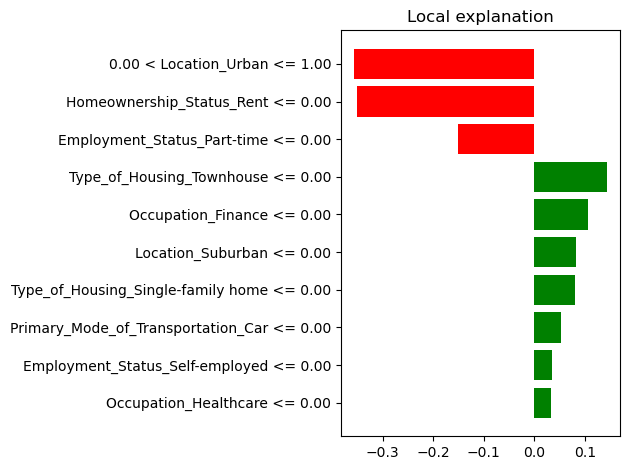

In [50]:
# Apply the preprocessor to get the processed data
X_processed = preprocessor.transform(X)

# Get the feature names from the preprocessor (if using OneHotEncoder, etc.)
# This example assumes that your preprocessor is a ColumnTransformer and one step might be OneHotEncoder
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_columns)
ordinal_feature_names = ordinal_columns  # These names should remain the same
numerical_feature_names = numerical_columns  # These names should remain the same

# Combine all feature names together
feature_names = np.concatenate([onehot_feature_names, ordinal_feature_names, numerical_feature_names])

# Initialize the LIME explainer with the correct feature names
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_processed,
    feature_names=feature_names,
    mode='regression'
)

# Select an instance to explain (e.g., the first instance)
i = 0  # You can change this index to explain different instances
exp = explainer.explain_instance(X_processed[i], xgb_model.predict)

# Display the explanation
exp.show_in_notebook(show_all=False)
ig = plt.figure(figsize=(12, 8))  # Increase the figure size
exp.as_pyplot_figure()

plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()

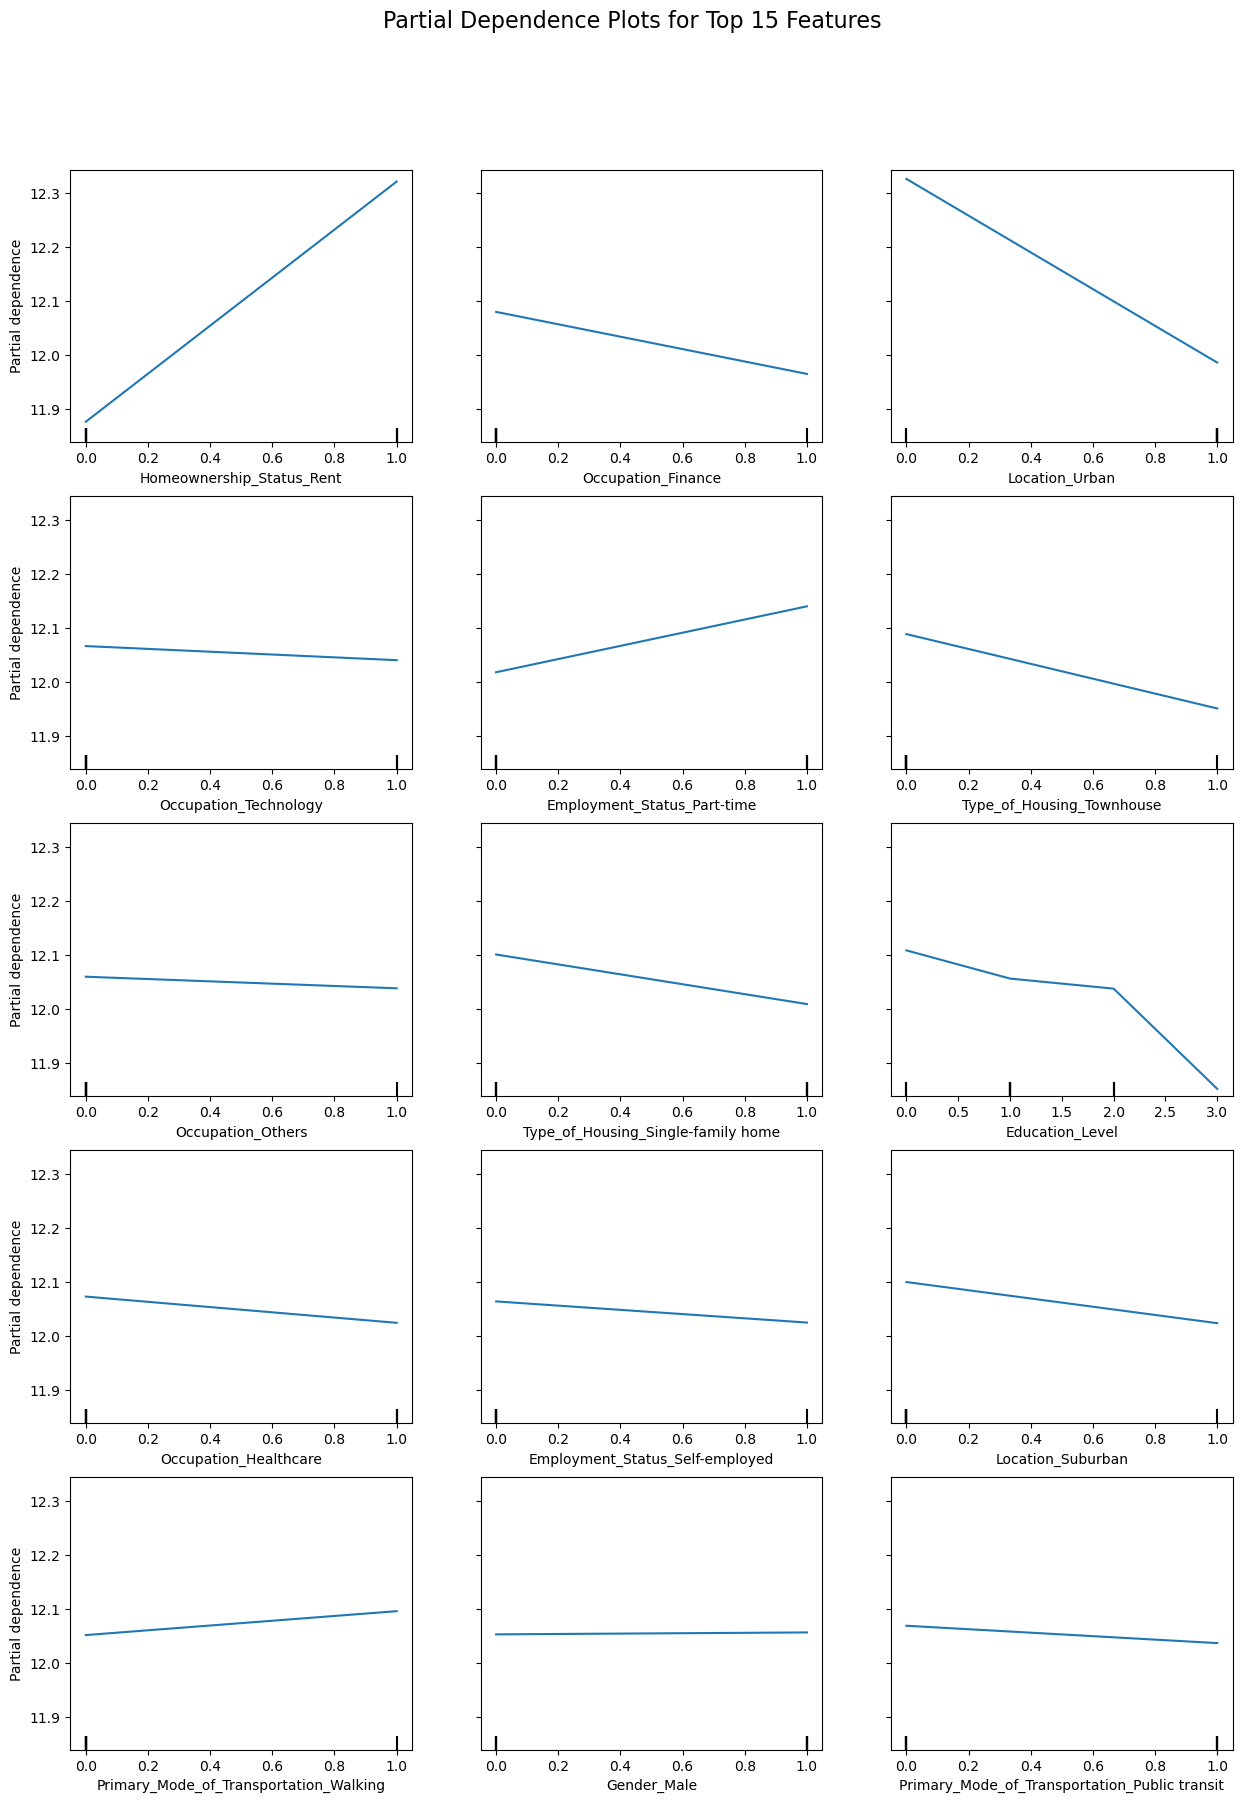

In [52]:
# Apply the preprocessor to get the processed data
X_processed = preprocessor.transform(X)

# Determine the top 15 features by importance
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Get indices of top 15 features

# Get the correct feature names after preprocessing
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_columns)
ordinal_feature_names = ordinal_columns
numerical_feature_names = numerical_columns
feature_names = np.concatenate([onehot_feature_names, ordinal_feature_names, numerical_feature_names])

# Create a list of the top 15 feature names
top_15_features = [feature_names[i] for i in indices]

# Create the Partial Dependence Plots for the top 15 features
fig, ax = plt.subplots(figsize=(15, 20))  # Adjust size as needed for clarity

# Use PartialDependenceDisplay.from_estimator
PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_processed,
    features=indices,  # Indices of the top features
    feature_names=feature_names,  # Use the correct feature names
    grid_resolution=50,
    ax=ax
)

plt.subplots_adjust(top=0.9)  # Adjust layout to make room for titles/labels
plt.suptitle('Partial Dependence Plots for Top 15 Features', fontsize=16)  # Add a title
plt.show()

### Partial Dependence Plots (PDPs) for Top 15 Features

The Partial Dependence Plots (PDPs) provide insight into how each of the top 15 features influences the predicted log-transformed income, holding all other features constant. Here's an interpretation of the key observations from these plots:

1. **Homeownership_Status_Rent:**
   - A clear positive relationship is observed, indicating that renting is associated with a higher predicted income. This may seem counterintuitive and might suggest a potential bias in the model or the underlying data.

2. **Occupation_Finance:**
   - There is a negative relationship, suggesting that working in finance slightly decreases the predicted income compared to other occupations.

3. **Type_of_Housing_Townhouse:**
   - Similar to the previous occupation, living in a townhouse appears to slightly decrease the predicted income.

4. **Employment_Status_Part-time:**
   - Part-time employment has a positive impact on predicted income. This could indicate that part-time workers in the dataset have other income sources or characteristics that lead to higher predicted income.

5. **Location_Urban:**
   - Urban living is associated with a lower predicted income, which could be due to various factors like higher living costs or specific data characteristics.

6. **Occupation_Technology:**
   - Working in technology has a slight negative impact on predicted income, which might indicate that other industries in the dataset are associated with higher income levels.

7. **Occupation_Healthcare:**
   - A slight negative trend is observed for those working in healthcare.

8. **Education_Level:**
   - Higher education levels (especially moving from 2.0 to 3.0, corresponding to "Master's" to "Doctorate") show a decreasing trend in predicted income. This could indicate diminishing returns on income for higher education levels in this specific dataset.

9. **Employment_Status_Self-employed:**
   - Being self-employed slightly decreases the predicted income.

10. **Location_Suburban:**
    - Suburban living also shows a slight negative trend, similar to urban living.

11. **Type_of_Housing_Single-family home:**
    - Living in a single-family home has a negative impact on predicted income.

12. **Marital_Status_Single:**
    - Being single has a negligible impact on predicted income, as seen by the nearly flat line.

13. **Primary_Mode_of_Transportation_Walking:**
    - Walking as a primary mode of transportation slightly increases the predicted income.

14. **Gender_Male:**
    - The gender (male) feature shows a very slight positive impact on predicted income.

15. **Occupation_Others:**
    - Other occupations have a negligible impact, as indicated by the flat line.

### Summary:

- **Overall Trends:** The PDPs reveal some counterintuitive relationships, such as renting or part-time employment being associated with higher predicted incomes. This could indicate underlying patterns or biases in the data that should be further investigated.
- **Feature Influence:** Most features have a relatively small impact on the predicted income, as evidenced by the slight slopes of the lines. This suggests that while these features are important, their individual contributions to the overall prediction might be limited.
- **Model Interpretation:** These PDPs are valuable for understanding how the model uses these features to make predictions. However, they should be interpreted with caution, especially when trends appear counterintuitive, as this could point to potential issues with the model or data.